# Разработка алгоритма расчета состояния прибытия пожарных подразделений к зданиям

In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.mclp import BestNodesKoptG
from genesis.tools import list_dict_concat
from genesis.utils import timing
import matplotlib.pyplot as plt
from genesis.swiss_knife import CMAP_GrGldRd

import osmnx as ox

In [2]:
# Загрузка графа, полигона границ и зданий
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")
buildings = gpd.read_file("tests/data/buildings.gpkg", layer="здания")
buildings.head()

,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,Спрос,geometry
0,114435873,NaN,NaN,Многоквартирный жилой дом,улица Ленинского Комсомола,2,9,NaN,0.014152,"POLYGON ((93.34238 56.12589, 93.34250 56.12597..."
1,114435874,NaN,NaN,Торговое здание,улица Ленинского Комсомола,NaN,NaN,NaN,0.003726,"POLYGON ((93.33886 56.12348, 93.33875 56.12340..."
2,114435883,NaN,NaN,Многоквартирный жилой дом,улица Ленинского Комсомола,14,9,NaN,0.014152,"POLYGON ((93.33509 56.12247, 93.33522 56.12256..."
3,114435884,Айсберг,NaN,Торговое здание,улица Ленинского Комсомола,16,2,NaN,0.003726,"POLYGON ((93.33517 56.12089, 93.33507 56.12093..."
4,114435890,NaN,NaN,Торговое здание,улица Ленинского Комсомола,10,2,NaN,0.003726,"POLYGON ((93.33343 56.12335, 93.33358 56.12328..."


## Разработка

In [7]:
nodes_gdf = ox.project_gdf(ox.graph_to_gdfs(G, edges=False))
nodes_gdf['node'] = nodes_gdf.index
buildings = ox.project_gdf(buildings)

In [36]:
buildings_new = buildings.sjoin_nearest(nodes_gdf[['geometry']], max_distance=100)
buildings_new.rename(columns={'index_right': 'node'}, inplace=True)
buildings_new.head(2)

,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,Спрос,geometry,node
0,114435873,NaN,NaN,Многоквартирный жилой дом,улица Ленинского Комсомола,2,9,NaN,0.014152,"POLYGON ((521283.901 6220143.312, 521291.376 6...",9085465307
1,114435874,NaN,NaN,Торговое здание,улица Ленинского Комсомола,NaN,NaN,NaN,0.003726,"POLYGON ((521066.656 6219874.938, 521059.407 6...",9085465281


<Axes: >

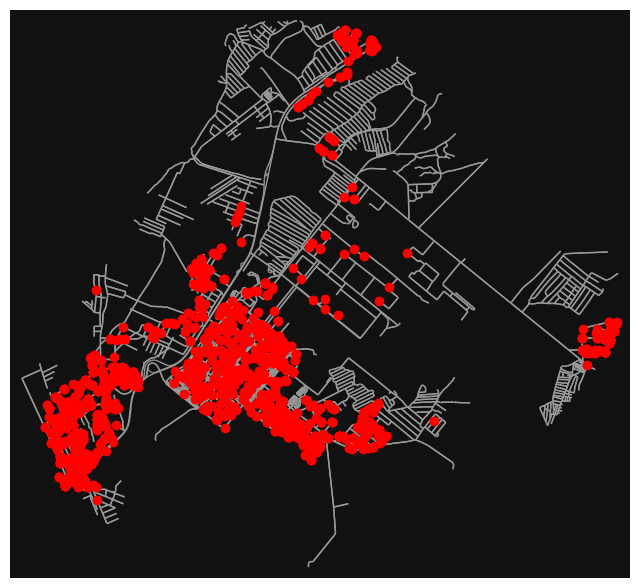

In [32]:
fig, ax = ox.plot_graph(G, node_size=0, show=False)
nodes_gdf2 = ox.graph_to_gdfs(G, edges=False)
nodes_gdf2.loc[buildings_new['node']].plot(ax=ax, c='r')

In [ ]:
class FireUnitsDemandSatisfyState(FirstArrivalUnitState):
    def __init__(self, state_algorithm=..., weight='travel_time', delay=..., **kwargs):
        super().__init__(state_algorithm, weight, delay, **kwargs)

    def __call__(self,
                 env,
                 points,
                 buildings: gpd.GeoDataFrame,
                 area=None,
                 **kwargs):


        # Вот это будет вызывать базовый алгоритм:
        times, nearest = super().__call__(env, points, area, **kwargs)


        print(type(times))
        # здесь сопоставляем building и times
        merged_df = pd.merge(buildings, times, left_on='node', right_index=True)
        